# YZM0206 Proje - MobileNetV2 Transfer Learning ve Fine-tuning

Bu notebookta EuroSAT RGB veri seti üzerinde MobileNetV2 modeli kullanılarak transfer learning ve fine-tuning uygulanmıştır. Projenin bu bölümü, hazır ağırlıklı bir evrişimli sinir ağının seçilen veri setine nasıl uyarlandığını göstermek için hazırlanmıştır.

Bu notebookun projedeki yeri:

1. İlk notebookta veri seti incelenmiş ve sabit train / validation / test ayrımı oluşturulmuştur.
2. İkinci notebookta hazır ağırlık kullanmadan baseline CNN modeli eğitilmiştir.
3. Bu notebookta ImageNet üzerinde önceden eğitilmiş MobileNetV2 modeli EuroSAT sınıflandırma problemine uyarlanmıştır.

Bu çalışma iki aşamadan oluşur:

1. Feature extraction: MobileNetV2 tabanı dondurulur ve sadece yeni sınıflandırma katmanları eğitilir.
2. Fine-tuning: MobileNetV2 tabanının son katmanlarından bir kısmı düşük learning rate ile tekrar eğitilir.

Amaç sadece yüksek accuracy almak değildir. Amaç, hazır öğrenilmiş görsel özelliklerin EuroSAT veri setinde ne kadar fayda sağladığını ve fine-tuning adımının performansa etkisini ölçmektir.

## Kütüphaneler ve proje dizinleri

Bu bölümde model eğitimi, değerlendirme ve görselleştirme için gerekli kütüphaneler içe aktarılmıştır. Rastgelelik kontrolü için seed değeri sabitlenmiştir. Böylece veri okuma sırası ve eğitim başlangıcı mümkün olduğunca tekrar üretilebilir hale getirilmiştir.

Ayrıca proje içindeki data, figures, models ve reports klasörleri tanımlanmıştır. Eğitim çıktıları bu klasörlere kaydedileceği için sonraki karşılaştırma notebookunda aynı dosyalar tekrar kullanılabilecektir.

In [1]:
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def prepare_local_split_from_zip():
    if not SPLIT_ZIP_PATH.exists():
        raise FileNotFoundError("Split zip dosyası bulunamadı. Önce 01_dataset_preparation.ipynb çalıştırılmalıdır.")

    expected = split_zip_counts(SPLIT_ZIP_PATH)

    if sum(expected.values()) != 27000:
        raise RuntimeError("Split zip dosyası beklenen 27000 görüntüyü içermiyor.")

    split_ready = all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items())

    if split_ready:
        return

    if SPLIT_ROOT.exists():
        shutil.rmtree(SPLIT_ROOT)

    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(SPLIT_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SPLIT_ROOT)

    if not all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items()):
        raise RuntimeError("Split zip dosyası çalışma alanına eksik çıkarıldı.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}
TRAIN_DIR = SPLIT_DIRS["train"]
VALID_DIR = SPLIT_DIRS["valid"]
TEST_DIR = SPLIT_DIRS["test"]

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

prepare_local_split_from_zip()

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)
print("Train görüntü sayısı:", count_images(TRAIN_DIR))
print("Validation görüntü sayısı:", count_images(VALID_DIR))
print("Test görüntü sayısı:", count_images(TEST_DIR))

Mounted at /content/drive
Hazırlık tamamlandı.
TensorFlow: 2.20.0
Train görüntü sayısı: 18900
Validation görüntü sayısı: 4050
Test görüntü sayısı: 4050


## Veri kümelerini yükleme

Bu bölümde ilk notebookta oluşturulan sabit train / validation / test ayrımı yüklenmiştir. Aynı split dosyasının kullanılması önemlidir; çünkü baseline CNN ve transfer learning modellerinin aynı veri üzerinde karşılaştırılması gerekir.

Görüntüler MobileNetV2 girişine uygun olacak şekilde 224x224 boyutunda okunmuştur. Bu aşamada ayrıca sınıf isimleri alınmış ve sınıf sayısı belirlenmiştir. Etiketler sparse integer formatında tutulmuştur; bu nedenle modelde sparse categorical crossentropy loss fonksiyonu kullanılacaktır.

Train kümesinde shuffle açıktır çünkü modelin her epochta görüntüleri farklı sırada görmesi öğrenmeye yardımcı olur. Validation ve test kümelerinde shuffle kapalıdır; böylece değerlendirme ve confusion matrix sonuçları daha izlenebilir olur.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

dataset_sizes = {
    "train": count_images(TRAIN_DIR),
    "valid": count_images(VALID_DIR),
    "test": count_images(TEST_DIR),
}

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)
print("Veri bölünmesi:", dataset_sizes)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Sınıf sayısı: 10
Sınıflar: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Veri bölünmesi: {'train': 18900, 'valid': 4050, 'test': 4050}


## Veri pipeline hazırlığı

Bu adımda prefetch kullanılmıştır. Prefetch, model bir batch üzerinde eğitim yaparken bir sonraki batchin arka planda hazırlanmasını sağlar. Bu işlem modelin sonucunu değiştirmez; sadece veri okuma ve eğitim akışını daha verimli hale getirir.

Normalizasyon bu bölümde ayrıca yapılmamıştır. Çünkü MobileNetV2, ImageNet üzerinde kendi preprocessing mantığıyla eğitilmiştir. Bu nedenle piksel ölçekleme işlemi model mimarisi içinde MobileNetV2 preprocessing fonksiyonu ile uygulanacaktır.

In [3]:
train_data = train_data.prefetch(AUTOTUNE)
valid_data = valid_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## MobileNetV2 preprocessing ve augmentation

MobileNetV2 modeli ImageNet üzerinde belirli bir giriş ölçeğiyle eğitilmiştir. Bu nedenle görüntüler modele verilmeden önce MobileNetV2 için tanımlı preprocess input fonksiyonundan geçirilmiştir. Baseline CNN'deki 0-1 normalizasyon yerine burada modelin kendi preprocessing fonksiyonunun kullanılması daha doğru bir yaklaşımdır.

Bu notebookta sınırlı geometrik augmentation da kullanılmıştır. Flip, rotation, zoom ve translation gibi işlemler uydu görüntülerinde genel olarak anlamlıdır; çünkü arazi sınıfı çoğu zaman görüntünün yönünden bağımsızdır. Renk tabanlı brightness ve contrast işlemleri bu ana deneye eklenmemiştir. EuroSAT RGB görüntülerinde renk ve doku sınıf ayrımı için önemli olabileceğinden, transfer learning deneyi daha kontrollü tutulmuştur.

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

print("MobileNetV2 preprocessing ve augmentation katmanları hazır.")

MobileNetV2 preprocessing ve augmentation katmanları hazır.


## MobileNetV2 model mimarisi

Bu bölümde ImageNet üzerinde önceden eğitilmiş MobileNetV2 tabanı alınmıştır. include_top parametresi False seçilmiştir; çünkü ImageNet'in orijinal 1000 sınıflı çıkış katmanı bu problem için uygun değildir. EuroSAT veri setinde 10 sınıf olduğu için modelin sonuna yeni bir sınıflandırıcı başlık eklenmiştir.

Mimarideki temel parçalar:

1. MobileNetV2 convolutional tabanı hazır görsel özellikleri çıkarır.
2. GlobalAveragePooling2D katmanı özellik haritalarını daha kompakt bir vektöre indirir.
3. Dropout katmanı overfitting riskini azaltmaya yardımcı olur.
4. Dense softmax katmanı 10 EuroSAT sınıfı için olasılık üretir.

İlk aşamada MobileNetV2 tabanı dondurulmuştur. Böylece model yalnızca yeni eklenen sınıflandırma katmanlarını öğrenir.

In [5]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,), name="input_layer")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

feature_trainable_params = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
print("Feature extraction aşamasındaki eğitilebilir parametre sayısı:", feature_trainable_params)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Feature extraction aşamasındaki eğitilebilir parametre sayısı: 12810


## Feature extraction eğitimi

Feature extraction aşamasında MobileNetV2 tabanı dondurulmuştur. Bu nedenle model ImageNet'ten öğrendiği genel görsel özellikleri kullanır, fakat bu özelliklerin EuroSAT sınıflarına nasıl bağlanacağını yeni eklenen son katmanlar öğrenir.

Bu aşama transfer learning'in temel etkisini ölçmek için önemlidir. Eğer validation accuracy baseline CNN'e göre belirgin şekilde iyileşirse, hazır ağırlıkların veri seti için faydalı olduğu söylenebilir.

Eğitimde iki callback kullanılmıştır:

1. ModelCheckpoint en iyi validation accuracy değerini veren modeli kaydeder.
2. ReduceLROnPlateau validation loss iyileşmediğinde learning rate değerini azaltır.
3. EarlyStopping validation accuracy uzun süre iyileşmezse eğitimi durdurur ve en iyi ağırlıkları geri yükler.

In [6]:
FEATURE_EPOCHS = 15

feature_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "mobilenetv2_feature_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_feature = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FEATURE_EPOCHS,
    callbacks=feature_callbacks
)

feature_training_time = time.time() - start_time
print("Feature extraction eğitim süresi (sn):", round(feature_training_time, 2))

Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7203 - loss: 0.8368
Epoch 1: val_accuracy improved from None to 0.90296, saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_feature_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_feature_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.8157 - loss: 0.5396 - val_accuracy: 0.9030 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 2/15
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8783 - loss: 0.3485
Epoch 2: val_accuracy improved from 0.90296 to 0.91654, saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_feature_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_feature_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 77s 74ms/step - accuracy: 0.8816 - loss: 0.3428 - val_accuracy: 0.9165 - val_loss: 0.2489 - learning_rate: 0.0010
Epoch 3/15
590/591 ━━━━━━━━━━

In [7]:
feature_history_df = pd.DataFrame(history_feature.history)
feature_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.815714,0.539572,0.902963,0.287399,0.0010
1,0.881640,0.342793,0.916543,0.248939,0.0010
2,0.892434,0.316348,0.918272,0.242686,0.0010
3,0.899471,0.301723,0.919012,0.235853,0.0010
4,0.902063,0.285832,0.922469,0.232608,0.0010
5,0.903704,0.287592,0.923457,0.217585,0.0010
6,0.902275,0.286922,0.925926,0.223632,0.0010
7,0.901534,0.282525,0.926420,0.210307,0.0010
8,0.903069,0.278470,0.926173,0.212927,0.0010
9,0.902434,0.284849,0.931358,0.210086,0.0010


## Feature extraction ara değerlendirmesi

Bu değerlendirme test kümesi üzerinde değil, validation kümesi üzerinde yapılmıştır. Amaç fine-tuning öncesinde modelin durumunu görmek ve sonraki aşamada gerçekten bir iyileşme olup olmadığını karşılaştırabilmektir.

Feature extraction sonunda validation loss 0.2101, validation accuracy ise 0.9314 olarak ölçülmüştür. Bu değer, sadece yeni sınıflandırıcı katmanlar eğitilmesine rağmen MobileNetV2'nin ImageNet'ten öğrendiği görsel özelliklerin EuroSAT için oldukça yararlı olduğunu göstermektedir.

Test kümesi final performans için saklanır. Böylece model seçiminde doğrudan test sonucuna göre karar verilmemiş olur.

In [8]:
feature_val_loss, feature_val_accuracy = model.evaluate(valid_data)

print("Feature extraction validation loss değeri:", feature_val_loss)
print("Feature extraction validation accuracy değeri:", feature_val_accuracy)

127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9314 - loss: 0.2101
Feature extraction validation loss değeri: 0.21008557081222534
Feature extraction validation accuracy değeri: 0.9313580393791199


## Feature extraction yorumu

Feature extraction aşamasında model 14 epoch çalışmıştır. İlk epochta validation accuracy 0.9030 iken bu değer eğitim sonunda 0.9314 seviyesine çıkmıştır. Bu sonuç, MobileNetV2 tabanı dondurulmuş olsa bile hazır ImageNet ağırlıklarının EuroSAT sınıflarını ayırmada güçlü bir başlangıç sağladığını göstermektedir.

Baseline CNN modelinin en iyi validation accuracy değeri 0.8133 idi. MobileNetV2 feature extraction aşamasında bu değerin yaklaşık 11.8 yüzde puan üzerine çıkmıştır. Bu fark transfer learning yaklaşımının projedeki temel katkısını açıkça göstermektedir.

## Fine-tuning hazırlığı

Fine-tuning aşamasında MobileNetV2 tabanının son katmanlarından bir kısmı tekrar eğitime açılmıştır. Erken katmanlar genellikle kenar, renk geçişi ve temel doku gibi genel özellikleri öğrenir. Son katmanlar ise veri setine daha özel örüntülerle ilişkilidir. Bu yüzden sadece son bölümün açılması daha kontrollü bir yaklaşımdır.

Bu notebookta MobileNetV2 tabanının son 30 katmanı eğitime açılmıştır. BatchNormalization katmanları ise dondurulmuştur. Bu tercih fine-tuning sırasında eğitim sürecini daha stabil tutmak için yaygın kullanılan bir yaklaşımdır.

Fine-tuning için learning rate 1e-5 seçilmiştir. Bu değer feature extraction aşamasındaki learning rate değerinden daha küçüktür; çünkü hazır ağırlıkların ani şekilde bozulmaması gerekir.

In [9]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization katmanlarını dondurmak fine-tuning sürecini daha stabil hale getirir.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
trainable_layer_names = [layer.name for layer in base_model.layers if layer.trainable]

print("MobileNetV2 toplam katman sayısı:", len(base_model.layers))
print("Fine-tuning için eğitilebilir katman sayısı:", trainable_layers)
print("Eğitilebilir son katmanlardan örnekler:", trainable_layer_names[:5])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

MobileNetV2 toplam katman sayısı: 154
Fine-tuning için eğitilebilir katman sayısı: 19
Eğitilebilir son katmanlardan örnekler: ['block_14_expand', 'block_14_expand_relu', 'block_14_depthwise', 'block_14_depthwise_relu', 'block_14_project']


## Fine-tuning eğitimi

Bu aşamada model tekrar eğitilmiştir. Fark şu şekildedir: artık yalnızca son sınıflandırıcı katmanlar değil, MobileNetV2 tabanının son bölümündeki bazı katmanlar da güncellenmektedir.

Beklenen sonuç, feature extraction aşamasındaki performansın üzerine küçük ama daha anlamlı bir iyileşme gelmesidir. Ancak fine-tuning her zaman accuracy değerini artırmak zorunda değildir. Eğer validation loss yükselirse veya validation accuracy düşerse, model veri setine fazla uyum sağlamaya başlamış olabilir.

In [10]:
FINE_TUNE_EPOCHS = 10

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "mobilenetv2_finetuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

fine_tuning_time = time.time() - start_time
print("Fine-tuning eğitim süresi (sn):", round(fine_tuning_time, 2))

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9064 - loss: 0.2681
Epoch 1: val_accuracy improved from None to 0.93333, saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_finetuned_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.9101 - loss: 0.2577 - val_accuracy: 0.9333 - val_loss: 0.1884 - learning_rate: 1.0000e-05
Epoch 2/10
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9259 - loss: 0.2256
Epoch 2: val_accuracy improved from 0.93333 to 0.93432, saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/mobilenetv2_finetuned_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.9240 - loss: 0.2258 - val_accuracy: 0.9343 - val_loss: 0.1842 - learning_rate: 1.0000e-05
Epoch 3/10
59

In [11]:
fine_history_df = pd.DataFrame(history_fine.history)
fine_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.910053,0.257666,0.933333,0.188352,0.000010
1,0.923968,0.225806,0.934321,0.184173,0.000010
2,0.928519,0.210408,0.944691,0.160292,0.000010
3,0.931429,0.201902,0.940741,0.162955,0.000010
4,0.935608,0.183631,0.948148,0.146220,0.000010
5,0.939365,0.180644,0.951852,0.139146,0.000010
6,0.937460,0.174849,0.945432,0.160486,0.000010
7,0.943862,0.166545,0.942222,0.158027,0.000010
8,0.945291,0.156349,0.954321,0.137394,0.000005
9,0.949524,0.147037,0.954074,0.134629,0.000005


## Eğitim grafiklerinin hazırlanması

Feature extraction ve fine-tuning iki ayrı eğitim aşaması olduğu için bu bölümde iki history nesnesi birleştirilmiştir. Grafikte dikey çizgi fine-tuning başlangıcını gösterir.

Bu grafikler modelin öğrenme davranışını yorumlamak için kullanılacaktır. Özellikle train accuracy ile validation accuracy arasındaki fark, overfitting ihtimalini değerlendirmek açısından önemlidir.

In [12]:
def combine_histories(history_a, history_b):
    combined = {}
    keys = sorted(set(history_a.history.keys()) | set(history_b.history.keys()))

    for key in keys:
        combined[key] = history_a.history.get(key, []) + history_b.history.get(key, [])

    history_df = pd.DataFrame(combined)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.insert(
        1,
        "phase",
        ["feature_extraction"] * len(history_a.history["loss"]) + ["fine_tuning"] * len(history_b.history["loss"])
    )
    return history_df


history_df = combine_histories(history_feature, history_fine)
history_df

,epoch,phase,accuracy,learning_rate,loss,val_accuracy,val_loss
0,1,feature_extraction,0.815714,0.001000,0.539572,0.902963,0.287399
1,2,feature_extraction,0.881640,0.001000,0.342793,0.916543,0.248939
2,3,feature_extraction,0.892434,0.001000,0.316348,0.918272,0.242686
3,4,feature_extraction,0.899471,0.001000,0.301723,0.919012,0.235853
4,5,feature_extraction,0.902063,0.001000,0.285832,0.922469,0.232608
5,6,feature_extraction,0.903704,0.001000,0.287592,0.923457,0.217585
6,7,feature_extraction,0.902275,0.001000,0.286922,0.925926,0.223632
7,8,feature_extraction,0.901534,0.001000,0.282525,0.926420,0.210307
8,9,feature_extraction,0.903069,0.001000,0.278470,0.926173,0.212927
9,10,feature_extraction,0.902434,0.001000,0.284849,0.931358,0.210086


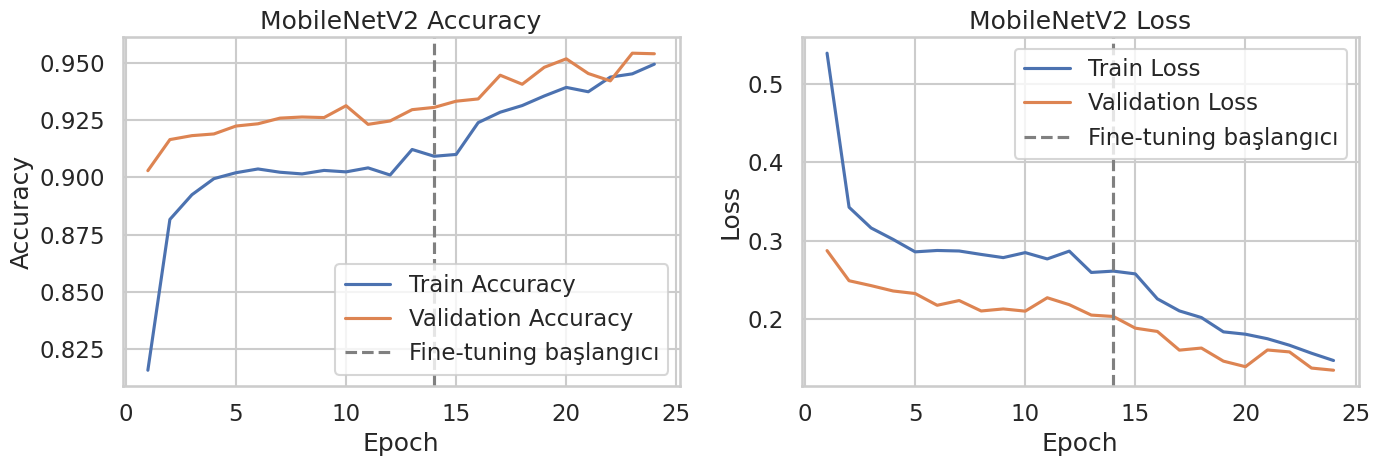

In [13]:
feature_epoch_count = len(history_feature.history["loss"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mobilenetv2_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Eğitim eğrilerinin yorumu

Feature extraction aşamasında en iyi validation accuracy 0.9314 olarak elde edilmiştir. Fine-tuning sonrasında en iyi validation accuracy 0.9543 seviyesine yükselmiştir. Bu yaklaşık 2.3 yüzde puanlık artış, MobileNetV2 tabanının son katmanlarını açmanın veri setine uyumu artırdığını göstermektedir.

Son epochta train accuracy 0.9495, validation accuracy ise 0.9541 değerindedir. Validation accuracy değerinin train accuracy değerine çok yakın olması, bu aşamada güçlü bir overfitting belirtisi olmadığını düşündürmektedir. Validation loss değerinin fine-tuning sonunda 0.1346 seviyesine kadar düşmesi de modelin daha dengeli tahminler üretmeye başladığını göstermektedir.

Bu sonuçlara göre MobileNetV2 için fine-tuning aşaması yalnızca teorik bir ek adım olmamış, sayısal olarak da performans artışı sağlamıştır.

## Test kümesi değerlendirmesi

Test kümesi eğitim sırasında kullanılmamıştır. Bu nedenle final performans değerlendirmesi bu bölümde yapılmıştır. Validation kümesi modelin eğitim sürecini takip etmek için kullanılırken, test kümesi modelin daha tarafsız başarısını ölçmek için ayrılmıştır.

MobileNetV2 modeli test kümesinde 0.9578 accuracy ve 0.1286 loss değerine ulaşmıştır. Bu sonuç, baseline CNN modelinin 0.8207 test accuracy değerine göre yaklaşık 13.7 yüzde puanlık bir artış anlamına gelmektedir.

In [14]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test loss değeri:", test_loss)
print("Test accuracy değeri:", test_accuracy)

127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9578 - loss: 0.1286
Test loss değeri: 0.12860779464244843
Test accuracy değeri: 0.9577777981758118


## Tahminlerin alınması

Classification report ve confusion matrix hesaplamak için test kümesindeki gerçek etiketler ile model tahminleri ayrı listelerde toplanmıştır. Model her görüntü için 10 sınıfa ait olasılık üretir. En yüksek olasılığa sahip sınıf tahmin edilen sınıf olarak alınmıştır.

In [15]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Tahmin sayısı:", len(y_pred))

Tahmin sayısı: 4050


## Classification report

Accuracy tek başına yeterli değildir. Model genel olarak başarılı görünse bile bazı sınıflarda düşük performans gösterebilir. Bu nedenle precision, recall ve F1-score değerleri hesaplanmıştır.

Precision, modelin bir sınıf için yaptığı pozitif tahminlerin ne kadarının doğru olduğunu gösterir. Recall, o sınıfa ait gerçek örneklerin ne kadarının yakalandığını gösterir. F1-score ise precision ve recall değerlerini birlikte değerlendirir.

Macro ortalama her sınıfa eşit ağırlık verir. Weighted ortalama ise sınıf örnek sayılarını dikkate alır. EuroSAT tamamen eşit sınıflı olmadığı için iki ortalamanın birlikte verilmesi daha sağlıklı bir değerlendirme sağlar.

In [16]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORTS_DIR / "mobilenetv2_classification_report.csv", encoding="utf-8-sig")
report_df

,precision,recall,f1-score,support
AnnualCrop,0.938326,0.946667,0.942478,450.000000
Forest,0.979911,0.975556,0.977728,450.000000
HerbaceousVegetation,0.946067,0.935556,0.940782,450.000000
Highway,0.923858,0.970667,0.946684,375.000000
Industrial,0.966234,0.992000,0.978947,375.000000
Pasture,0.957447,0.900000,0.927835,300.000000
PermanentCrop,0.922078,0.946667,0.934211,375.000000
Residential,0.990991,0.977778,0.984340,450.000000
River,0.948787,0.938667,0.943700,375.000000
SeaLake,0.995475,0.977778,0.986547,450.000000


## Sınıf bazlı performans yorumu

Classification report incelendiğinde MobileNetV2 modelinin tüm sınıflarda yüksek performans verdiği görülmektedir. En yüksek F1-score değerleri SeaLake (0.9865), Residential (0.9843), Industrial (0.9789) ve Forest (0.9777) sınıflarında elde edilmiştir.

En düşük F1-score değerleri Pasture (0.9278), PermanentCrop (0.9342) ve HerbaceousVegetation (0.9408) sınıflarındadır. Bu sınıflar baseline CNN modelinde de daha zorlayıcı olan tarım ve bitki örtüsü gruplarına yakındır. Ancak en düşük F1-score değerinin bile 0.9278 olması, MobileNetV2 modelinin baseline'a göre çok daha dengeli bir sınıf performansı verdiğini göstermektedir.

Macro F1-score değeri 0.9563, weighted F1-score değeri ise 0.9578 olarak hesaplanmıştır. Bu değerler genel accuracy sonucunun sınıf bazında da desteklendiğini göstermektedir.

## Confusion matrix

Confusion matrix, modelin hangi sınıfları hangi sınıflarla karıştırdığını gösterir. Satırlar gerçek sınıfları, sütunlar tahmin edilen sınıfları temsil eder.

Bu analiz özellikle hata yorumları için önemlidir. Örneğin model PermanentCrop görüntülerini AnnualCrop olarak tahmin ediyorsa, bu iki sınıfın görsel benzerliği raporda tartışılabilir.

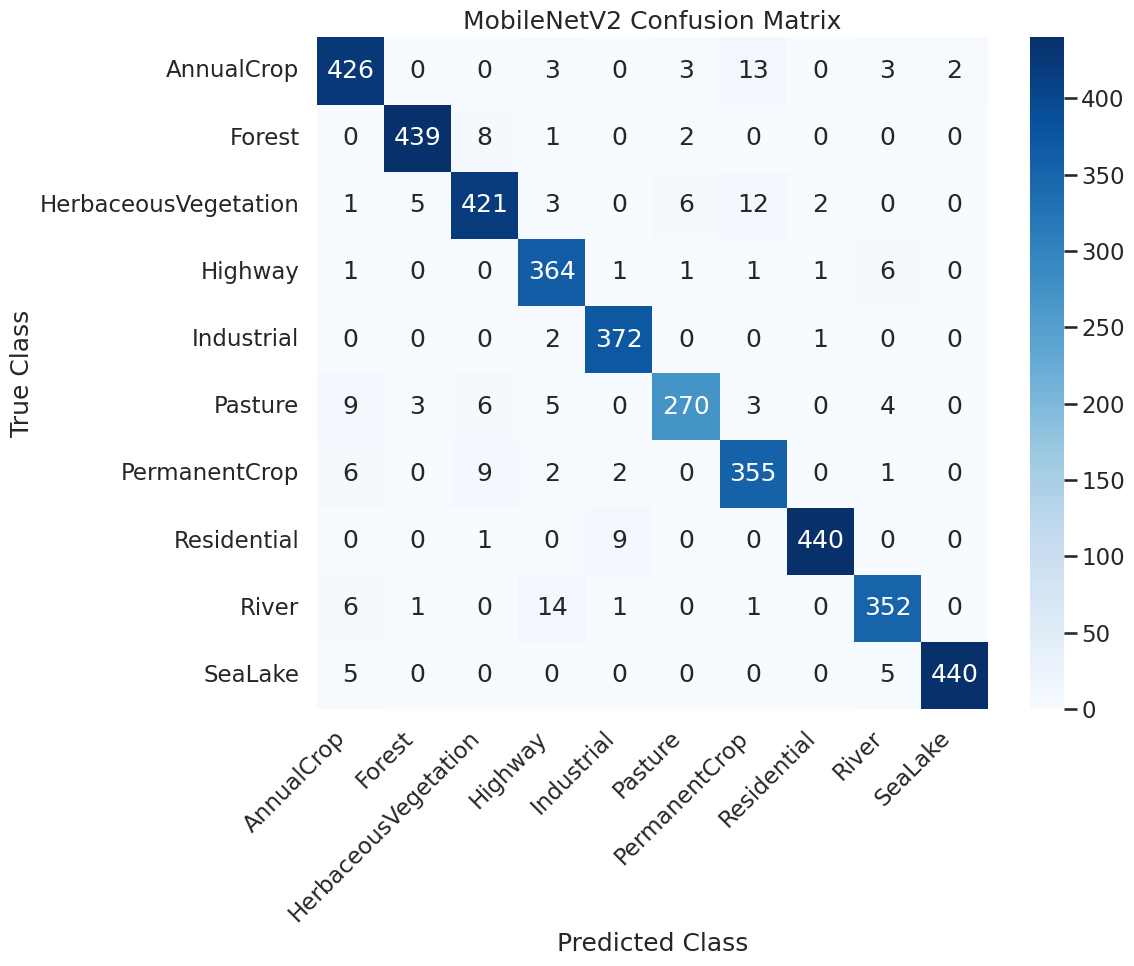

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mobilenetv2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix yorumu

Confusion matrix çıktısı, MobileNetV2 modelinin baseline CNN'e göre hata sayısını belirgin şekilde azalttığını göstermektedir. Classification reportta tüm sınıfların F1-score değerinin 0.92 üzerinde olması, hataların tek bir sınıfta yoğunlaşmadığını göstermektedir.

En zayıf sınıflar Pasture, PermanentCrop ve HerbaceousVegetation olarak kalmıştır. Bu durum tarım ve bitki örtüsü sınıflarının görsel benzerliğinin devam ettiğini, ancak transfer learning ile bu karışıklığın baseline modele göre oldukça azaldığını göstermektedir.

## Sonuçları kaydetme

Bu bölümde MobileNetV2 modeline ait temel sonuçlar dosyaya kaydedilmiştir. Kaydedilen dosyalar final karşılaştırma notebookunda tekrar okunacaktır.

Kaydedilen bilgiler:

1. Test accuracy ve test loss değerleri
2. Balanced accuracy
3. Macro ve weighted precision, recall, F1-score değerleri
4. Feature extraction ve fine-tuning eğitim süreleri
5. En iyi validation accuracy değerleri
6. Classification report tablosu
7. Eğitim geçmişi
8. En iyi model ağırlıkları

Bu kayıt yapısı, sonuçların sonradan rapora aktarılmasını ve modeller arasında adil karşılaştırma yapılmasını kolaylaştırır.

In [18]:
summary_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
}

metrics = {
    "model": "MobileNetV2",
    "method": "transfer_learning_and_fine_tuning",
    "augmentation_type": "geometric",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "feature_validation_loss": float(feature_val_loss),
    "feature_validation_accuracy": float(feature_val_accuracy),
    "best_feature_val_accuracy": float(max(history_feature.history["val_accuracy"])),
    "best_finetune_val_accuracy": float(max(history_fine.history["val_accuracy"])),
    "feature_epochs_ran": int(len(history_feature.history["loss"])),
    "fine_tune_epochs_ran": int(len(history_fine.history["loss"])),
    "feature_training_time_seconds": float(feature_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "total_training_time_seconds": float(feature_training_time + fine_tuning_time),
    "total_params": int(model.count_params()),
    "trainable_params_after_finetuning": int(sum(np.prod(weight.shape) for weight in model.trainable_weights)),
    "fine_tune_trainable_layers": int(trainable_layers),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "dataset_sizes": dataset_sizes,
    **summary_metrics,
}

metrics_path = REPORTS_DIR / "mobilenetv2_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

history_df.to_csv(REPORTS_DIR / "mobilenetv2_history.csv", index=False, encoding="utf-8-sig")
model.save(MODELS_DIR / "mobilenetv2_final.keras")

pd.DataFrame([metrics])

,model,method,augmentation_type,test_loss,test_accuracy,feature_validation_loss,feature_validation_accuracy,best_feature_val_accuracy,best_finetune_val_accuracy,feature_epochs_ran,...,class_names,dataset_sizes,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,MobileNetV2,transfer_learning_and_fine_tuning,geometric,0.128608,0.957778,0.210086,0.931358,0.931358,0.954321,14,...,"[AnnualCrop, Forest, HerbaceousVegetation, Hig...","{'train': 18900, 'valid': 4050, 'test': 4050}",0.957778,0.956133,0.956917,0.956133,0.956325,0.958133,0.957778,0.957783


## MobileNetV2 notebook özeti

Bu notebookta MobileNetV2 modeli ile transfer learning ve fine-tuning uygulanmıştır. Model 2.270.794 parametreye sahiptir ve fine-tuning sonrasında 1.523.530 parametre eğitilebilir hale gelmiştir.

Feature extraction aşamasında validation accuracy 0.9314, fine-tuning sonrasında en iyi validation accuracy 0.9543 olarak elde edilmiştir. Test kümesinde ise 0.9578 accuracy, 0.9563 macro F1-score ve 0.9578 weighted F1-score değerlerine ulaşılmıştır.

Baseline CNN'in test accuracy değeri 0.8207 olduğu için MobileNetV2 belirgin bir iyileşme sağlamıştır. Bu sonuç, ImageNet üzerinde önceden eğitilmiş ağırlıkların EuroSAT RGB veri setinde güçlü bir özellik çıkarıcı olarak kullanılabildiğini göstermektedir.